# Analyzing data with Pandas

First a little setup. Importing the pandas library as ```pd```

In [1]:
import pandas as pd

Set some helpful display options. Uncomment the boilerplate in this cell.

In [2]:
pd.set_option("display.max_columns", 150)
pd.set_option("display.max_colwidth", 40)
pd.options.display.float_format = '{:,.2f}'.format

open and read in the Master.csv and Salaries.csv tables in the ```data/2017/``` directory

In [3]:
master = pd.read_csv('../project3/data/2017/Master.csv') # File with player details
salary = pd.read_csv('../project3/data/2017/Salaries.csv') #File with baseball players' salaries

check to see what type each object is with `print(table_name)`. You can also use the ```.info()``` method to explore the data's structure.

In [4]:
master.info()

<class 'pandas.DataFrame'>
RangeIndex: 18846 entries, 0 to 18845
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   playerID      18846 non-null  str    
 1   birthYear     18703 non-null  float64
 2   birthMonth    18531 non-null  float64
 3   birthDay      18382 non-null  float64
 4   birthCountry  18773 non-null  str    
 5   birthState    18220 non-null  str    
 6   birthCity     18647 non-null  str    
 7   deathYear     9336 non-null   float64
 8   deathMonth    9335 non-null   float64
 9   deathDay      9334 non-null   float64
 10  deathCountry  9329 non-null   str    
 11  deathState    9277 non-null   str    
 12  deathCity     9325 non-null   str    
 13  nameFirst     18807 non-null  str    
 14  nameLast      18846 non-null  str    
 15  nameGiven     18807 non-null  str    
 16  weight        17975 non-null  float64
 17  height        18041 non-null  float64
 18  bats          17655 non-null  str    

In [5]:
salary.info()

<class 'pandas.DataFrame'>
RangeIndex: 25575 entries, 0 to 25574
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   yearID    25575 non-null  int64
 1   teamID    25575 non-null  str  
 2   lgID      25575 non-null  str  
 3   playerID  25575 non-null  str  
 4   salary    25575 non-null  int64
dtypes: int64(2), str(3)
memory usage: 999.2 KB


print out sample data for each table with `table.head()`<br>
see additional options by pressing `tab` after you type the `head()` method

In [6]:
master.head()

,playerID,birthYear,birthMonth,birthDay,birthCountry,birthState,birthCity,deathYear,deathMonth,deathDay,deathCountry,deathState,deathCity,nameFirst,nameLast,nameGiven,weight,height,bats,throws,debut,finalGame,retroID,bbrefID
0,aardsda01,"1,981.00",12.00,27.00,USA,CO,Denver,NaN,NaN,NaN,NaN,NaN,NaN,David,Aardsma,David Allan,220.00,75.00,R,R,2004-04-06,2015-08-23,aardd001,aardsda01
1,aaronha01,"1,934.00",2.00,5.00,USA,AL,Mobile,NaN,NaN,NaN,NaN,NaN,NaN,Hank,Aaron,Henry Louis,180.00,72.00,R,R,1954-04-13,1976-10-03,aaroh101,aaronha01
2,aaronto01,"1,939.00",8.00,5.00,USA,AL,Mobile,"1,984.00",8.00,16.00,USA,GA,Atlanta,Tommie,Aaron,Tommie Lee,190.00,75.00,R,R,1962-04-10,1971-09-26,aarot101,aaronto01
3,aasedo01,"1,954.00",9.00,8.00,USA,CA,Orange,NaN,NaN,NaN,NaN,NaN,NaN,Don,Aase,Donald William,190.00,75.00,R,R,1977-07-26,1990-10-03,aased001,aasedo01
4,abadan01,"1,972.00",8.00,25.00,USA,FL,Palm Beach,NaN,NaN,NaN,NaN,NaN,NaN,Andy,Abad,Fausto Andres,184.00,73.00,L,L,2001-09-10,2006-04-13,abada001,abadan01


In [7]:
salary.head()

,yearID,teamID,lgID,playerID,salary
0,1985,ATL,NL,barkele01,870000
1,1985,ATL,NL,bedrost01,550000
2,1985,ATL,NL,benedbr01,545000
3,1985,ATL,NL,campri01,633333
4,1985,ATL,NL,ceronri01,625000


Now we join the two csv's using `pd.merge`.<br>
We want to keep all the players names in the `master` data set<br>
even if their salary is missing from the `salary` data set.<br>
We can always filter the NaN values out later

In [8]:
joined = pd.merge(on = "playerID", left=master, right=salary, how="left")

see what columns the `joined` table contains

In [9]:
joined.info()

<class 'pandas.DataFrame'>
RangeIndex: 39455 entries, 0 to 39454
Data columns (total 28 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   playerID      39455 non-null  str    
 1   birthYear     39312 non-null  float64
 2   birthMonth    39140 non-null  float64
 3   birthDay      38991 non-null  float64
 4   birthCountry  39382 non-null  str    
 5   birthState    37738 non-null  str    
 6   birthCity     39228 non-null  str    
 7   deathYear     9669 non-null   float64
 8   deathMonth    9668 non-null   float64
 9   deathDay      9667 non-null   float64
 10  deathCountry  9662 non-null   str    
 11  deathState    9603 non-null   str    
 12  deathCity     9658 non-null   str    
 13  nameFirst     39416 non-null  str    
 14  nameLast      39455 non-null  str    
 15  nameGiven     39416 non-null  str    
 16  weight        38584 non-null  float64
 17  height        38650 non-null  float64
 18  bats          38264 non-null  str    

check if all the players have a salary assigned. The easiest way is to deduct the length of the `joined` table from the `master` table

In [10]:
len(master) - len(joined)

-20609

Something went wrong. There are now more players in the `joined` data set than in the `master` data set.<br>
Some entries probably got duplicated<br>
Let's check if we have duplicate `playerIDs` by using `.value_counts()`

In [11]:
joined["playerID"].value_counts()

playerID
moyerja01    25
vizquom01    24
glavito02    23
bondsba01    22
griffke02    22
             ..
zupofr01      1
zuvelpa01     1
zuverge01     1
zwilldu01     1
zychto01      1
Name: count, Length: 18846, dtype: int64

Yep, we do.<br>
Let's filter out an arbitrary player to see why there is duplication

In [12]:
joined[joined["playerID"] == "moyerja01"]

,playerID,birthYear,birthMonth,birthDay,birthCountry,birthState,birthCity,deathYear,deathMonth,deathDay,deathCountry,deathState,deathCity,nameFirst,nameLast,nameGiven,weight,height,bats,throws,debut,finalGame,retroID,bbrefID,yearID,teamID,lgID,salary
24836,moyerja01,"1,962.00",11.00,18.00,USA,PA,Sellersville,NaN,NaN,NaN,NaN,NaN,NaN,Jamie,Moyer,Jamie,170.00,72.00,L,L,1986-06-16,2012-05-27,moyej001,moyerja01,"1,986.00",CHN,NL,"60,000.00"
24837,moyerja01,"1,962.00",11.00,18.00,USA,PA,Sellersville,NaN,NaN,NaN,NaN,NaN,NaN,Jamie,Moyer,Jamie,170.00,72.00,L,L,1986-06-16,2012-05-27,moyej001,moyerja01,"1,987.00",CHN,NL,"70,000.00"
24838,moyerja01,"1,962.00",11.00,18.00,USA,PA,Sellersville,NaN,NaN,NaN,NaN,NaN,NaN,Jamie,Moyer,Jamie,170.00,72.00,L,L,1986-06-16,2012-05-27,moyej001,moyerja01,"1,988.00",CHN,NL,"142,500.00"
24839,moyerja01,"1,962.00",11.00,18.00,USA,PA,Sellersville,NaN,NaN,NaN,NaN,NaN,NaN,Jamie,Moyer,Jamie,170.00,72.00,L,L,1986-06-16,2012-05-27,moyej001,moyerja01,"1,989.00",TEX,AL,"205,000.00"
24840,moyerja01,"1,962.00",11.00,18.00,USA,PA,Sellersville,NaN,NaN,NaN,NaN,NaN,NaN,Jamie,Moyer,Jamie,170.00,72.00,L,L,1986-06-16,2012-05-27,moyej001,moyerja01,"1,990.00",TEX,AL,"340,000.00"
24841,moyerja01,"1,962.00",11.00,18.00,USA,PA,Sellersville,NaN,NaN,NaN,NaN,NaN,NaN,Jamie,Moyer,Jamie,170.00,72.00,L,L,1986-06-16,2012-05-27,moyej001,moyerja01,"1,991.00",SLN,NL,"200,000.00"
24842,moyerja01,"1,962.00",11.00,18.00,USA,PA,Sellersville,NaN,NaN,NaN,NaN,NaN,NaN,Jamie,Moyer,Jamie,170.00,72.00,L,L,1986-06-16,2012-05-27,moyej001,moyerja01,"1,993.00",BAL,AL,"200,000.00"
24843,moyerja01,"1,962.00",11.00,18.00,USA,PA,Sellersville,NaN,NaN,NaN,NaN,NaN,NaN,Jamie,Moyer,Jamie,170.00,72.00,L,L,1986-06-16,2012-05-27,moyej001,moyerja01,"1,994.00",BAL,AL,"725,000.00"
24844,moyerja01,"1,962.00",11.00,18.00,USA,PA,Sellersville,NaN,NaN,NaN,NaN,NaN,NaN,Jamie,Moyer,Jamie,170.00,72.00,L,L,1986-06-16,2012-05-27,moyej001,moyerja01,"1,995.00",BAL,AL,"1,100,000.00"
24845,moyerja01,"1,962.00",11.00,18.00,USA,PA,Sellersville,NaN,NaN,NaN,NaN,NaN,NaN,Jamie,Moyer,Jamie,170.00,72.00,L,L,1986-06-16,2012-05-27,moyej001,moyerja01,"1,996.00",BOS,AL,"825,000.00"


As we can see, there are now salaries in the dataset for each year of the players carreer.<br>
We only want to have the most recent salary though.<br>
We therefore need to 'deduplicate' the data set.

But first, let's make sure we get the newest year. We can do this by sorting the data on the newest entry

In [13]:
joined = joined.sort_values(["playerID","yearID"], ascending=True)

Now we deduplicate

In [14]:
deduplicated = joined.drop_duplicates("playerID", keep="last")

And let's do the check again

In [15]:
len(master) - len(deduplicated)

0

Now we van get into the interesting part: analysis!

## What is the average (mean, median, max, min) salary?

In [16]:
deduplicated["salary"].describe()

count        4,958.00
mean     1,692,477.94
std      3,243,005.10
min              0.00
25%        300,000.00
50%        507,500.00
75%      1,300,000.00
max     32,571,000.00
Name: salary, dtype: float64

## Who makes the most money?

In [17]:
max_salary = deduplicated["salary"].max()

In [18]:
deduplicated[deduplicated["salary"] == max_salary]

,playerID,birthYear,birthMonth,birthDay,birthCountry,birthState,birthCity,deathYear,deathMonth,deathDay,deathCountry,deathState,deathCity,nameFirst,nameLast,nameGiven,weight,height,bats,throws,debut,finalGame,retroID,bbrefID,yearID,teamID,lgID,salary
18735,kershcl01,"1,988.00",3.00,19.00,USA,TX,Dallas,NaN,NaN,NaN,NaN,NaN,NaN,Clayton,Kershaw,Clayton Edward,225.00,76.00,L,L,2008-05-25,2015-10-04,kersc001,kershcl01,"2,015.00",LAN,NL,"32,571,000.00"


## What are the most common baseball players salaries?

Draw a histogram. <br>

array([[<Axes: title={'center': 'salary'}>]], dtype=object)

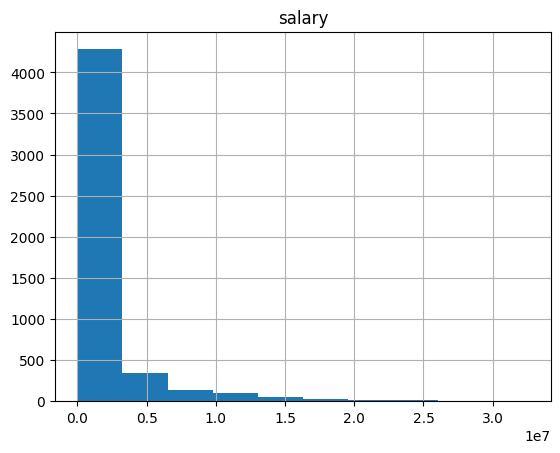

In [19]:
deduplicated.hist("salary")

We can do the same with the column `yearID` to see how recent our data is.<br>
We have 30 years in our data set, so we need to do some minor tweaking

array([[<Axes: title={'center': 'yearID'}>]], dtype=object)

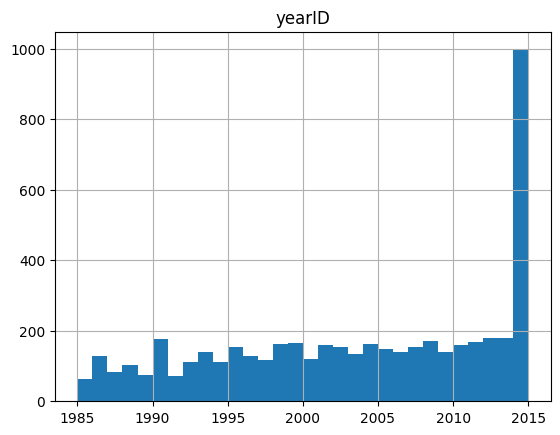

In [20]:
deduplicated.hist("yearID", bins=30)

## Who are the top 10% highest-paid players?

calculate the 90 percentile cutoff

In [21]:
top_10_p = deduplicated["salary"].quantile(q=0.9)
top_10_p

np.float64(4500000.0)

filter out players that make more money than the cutoff

In [22]:
best_paid = deduplicated[deduplicated["salary"] >= top_10_p]
best_paid

,playerID,birthYear,birthMonth,birthDay,birthCountry,birthState,birthCity,deathYear,deathMonth,deathDay,deathCountry,deathState,deathCity,nameFirst,nameLast,nameGiven,weight,height,bats,throws,debut,finalGame,retroID,bbrefID,yearID,teamID,lgID,salary
91,abreubo01,"1,974.00",3.00,11.00,Venezuela,Aragua,Maracay,NaN,NaN,NaN,NaN,NaN,NaN,Bobby,Abreu,Bob Kelly,220.00,72.00,L,R,1996-09-01,2014-09-28,abreb001,abreubo01,"2,012.00",LAA,AL,"9,000,000.00"
94,abreujo02,"1,987.00",1.00,29.00,Cuba,Cienfuegos,Cienfuegos,NaN,NaN,NaN,NaN,NaN,NaN,Jose,Abreu,Jose Dariel,255.00,75.00,R,R,2014-03-31,2015-10-03,abrej003,abreujo02,"2,015.00",CHA,AL,"8,666,000.00"
181,adamsmi03,"1,978.00",7.00,29.00,USA,TX,Corpus Christi,NaN,NaN,NaN,NaN,NaN,NaN,Mike,Adams,Jon Michael,210.00,77.00,R,R,2004-05-18,2014-09-18,adamm001,adamsmi03,"2,014.00",PHI,NL,"7,000,000.00"
237,affelje01,"1,979.00",6.00,6.00,USA,AZ,Phoenix,NaN,NaN,NaN,NaN,NaN,NaN,Jeremy,Affeldt,Jeremy David,225.00,76.00,L,L,2002-04-06,2015-10-04,affej001,affelje01,"2,015.00",SFN,NL,"6,000,000.00"
395,alfoned01,"1,973.00",11.00,8.00,Venezuela,Miranda,Santa Teresa del Tuy,NaN,NaN,NaN,NaN,NaN,NaN,Edgardo,Alfonzo,Edgardo Antonio,210.00,71.00,R,R,1995-04-26,2006-06-11,alfoe001,alfoned01,"2,006.00",LAA,AL,"8,000,000.00"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39364,zieglbr01,"1,979.00",10.00,10.00,USA,KS,Pratt,NaN,NaN,NaN,NaN,NaN,NaN,Brad,Ziegler,Brad Gregory,220.00,76.00,R,R,2008-05-31,2015-10-04,ziegb001,zieglbr01,"2,015.00",ARI,NL,"5,000,000.00"
39387,zimmejo02,"1,986.00",5.00,23.00,USA,WI,Auburndale,NaN,NaN,NaN,NaN,NaN,NaN,Jordan,Zimmermann,Jordan M.,225.00,74.00,R,R,2009-04-20,2015-09-30,zimmj003,zimmejo02,"2,015.00",WAS,NL,"16,500,000.00"
39397,zimmery01,"1,984.00",9.00,28.00,USA,NC,Washington,NaN,NaN,NaN,NaN,NaN,NaN,Ryan,Zimmerman,Ryan Wallace,220.00,75.00,R,R,2005-09-01,2015-09-07,zimmr001,zimmery01,"2,015.00",WAS,NL,"14,000,000.00"
39421,zitoba01,"1,978.00",5.00,13.00,USA,NV,Las Vegas,NaN,NaN,NaN,NaN,NaN,NaN,Barry,Zito,Barry William,205.00,74.00,L,L,2000-07-22,2015-09-30,zitob001,zitoba01,"2,013.00",SFN,NL,"20,000,000.00"


use the `nlargest` to see the top 10 best paid players

In [23]:
best_paid_top_10 = best_paid.nlargest(10, "salary")
best_paid_top_10

,playerID,birthYear,birthMonth,birthDay,birthCountry,birthState,birthCity,deathYear,deathMonth,deathDay,deathCountry,deathState,deathCity,nameFirst,nameLast,nameGiven,weight,height,bats,throws,debut,finalGame,retroID,bbrefID,yearID,teamID,lgID,salary
18735,kershcl01,"1,988.00",3.00,19.00,USA,TX,Dallas,NaN,NaN,NaN,NaN,NaN,NaN,Clayton,Kershaw,Clayton Edward,225.00,76.00,L,L,2008-05-25,2015-10-04,kersc001,kershcl01,"2,015.00",LAN,NL,"32,571,000.00"
36569,verlaju01,"1,983.00",2.00,20.00,USA,VA,Manakin Sabot,NaN,NaN,NaN,NaN,NaN,NaN,Justin,Verlander,Justin Brooks,225.00,77.00,R,R,2005-07-04,2015-10-03,verlj001,verlaju01,"2,015.00",DET,AL,"28,000,000.00"
13538,greinza01,"1,983.00",10.00,21.00,USA,FL,Orlando,NaN,NaN,NaN,NaN,NaN,NaN,Zack,Greinke,Donald Zachary,195.00,72.00,R,R,2004-05-22,2015-10-03,greiz001,greinza01,"2,015.00",LAN,NL,"25,000,000.00"
16479,howarry01,"1,979.00",11.00,19.00,USA,MO,St. Louis,NaN,NaN,NaN,NaN,NaN,NaN,Ryan,Howard,Ryan James,250.00,76.00,L,L,2004-09-01,2015-09-14,howar001,howarry01,"2,015.00",PHI,NL,"25,000,000.00"
20087,leecl02,"1,978.00",8.00,30.00,USA,AR,Benton,NaN,NaN,NaN,NaN,NaN,NaN,Cliff,Lee,Clifton Phifer,205.00,75.00,L,L,2002-09-15,2014-07-31,lee-c003,leecl02,"2,014.00",PHI,NL,"25,000,000.00"
15555,hernafe02,"1,986.00",4.00,8.00,Venezuela,Carabobo,Valencia,NaN,NaN,NaN,NaN,NaN,NaN,Felix,Hernandez,Felix Abraham,225.00,75.00,R,R,2005-08-04,2015-09-26,hernf002,hernafe02,"2,015.00",SEA,AL,"24,857,000.00"
37613,wellsve01,"1,978.00",12.00,8.00,USA,LA,Shreveport,NaN,NaN,NaN,NaN,NaN,NaN,Vernon,Wells,Vernon M.,230.00,73.00,R,R,1999-08-30,2013-09-29,wellv001,wellsve01,"2,013.00",NYA,AL,"24,642,857.00"
5384,canoro01,"1,982.00",10.00,22.00,D.R.,San Pedro de Macoris,San Pedro de Macoris,NaN,NaN,NaN,NaN,NaN,NaN,Robinson,Cano,Robinson Jose,210.00,72.00,L,R,2005-05-03,2015-10-04,canor001,canoro01,"2,015.00",SEA,AL,"24,000,000.00"
10823,fieldpr01,"1,984.00",5.00,9.00,USA,CA,Ontario,NaN,NaN,NaN,NaN,NaN,NaN,Prince,Fielder,Prince Semien,275.00,71.00,L,R,2005-06-13,2015-10-04,fielp001,fieldpr01,"2,015.00",TEX,AL,"24,000,000.00"
28702,pujolal01,"1,980.00",1.00,16.00,D.R.,Distrito Nacional,Santo Domingo,NaN,NaN,NaN,NaN,NaN,NaN,Albert,Pujols,Jose Alberto,230.00,75.00,R,R,2001-04-02,2015-10-04,pujoa001,pujolal01,"2,015.00",LAA,AL,"24,000,000.00"


draw a chart

<Axes: ylabel='nameLast'>

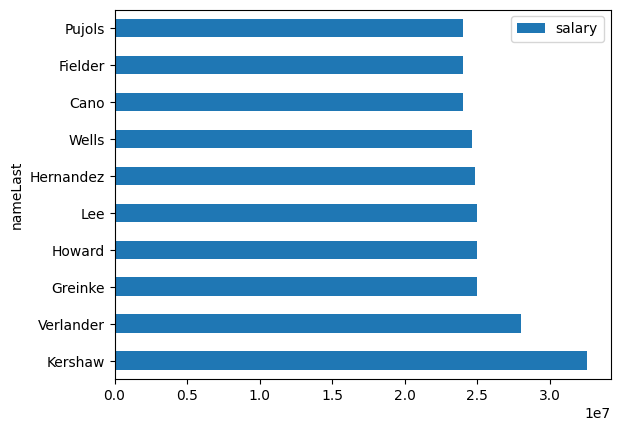

In [24]:
best_paid_top_10.plot(kind="barh", x="nameLast", y="salary")

save the data

In [25]:
best_paid.to_csv('highest-paid.csv', index=False)